In [1]:
# main imports

# standard libraries
import os

# data science and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

# tensorflow and keras
import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# google colab
from google.colab import drive

In [2]:
# environment and directory setup

from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

base_dir = '/content/gdrive/MyDrive/'

train_dir = os.path.join(base_dir, 'dataset-combined', 'treino')
test_dir = os.path.join(base_dir, 'dataset-combined', 'interpretabilidade')

Mounted at /content/gdrive


In [3]:
# model and training parameters

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE_TL = 3e-4
LEARNING_RATE_FT = 1e-5

In [4]:
# data augmentation setup

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

validation_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

In [5]:
# train and validation data generators

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = validation_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 267 images belonging to 2 classes.
Found 66 images belonging to 2 classes.


In [6]:
# test data generator

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 40 images belonging to 2 classes.


In [7]:
# class weight calculation

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(class_weights))
print(f"Calculated Weights: {class_weights_dict}")

Calculated Weights: {0: np.float64(1.0853658536585367), 1: np.float64(0.9270833333333334)}


In [8]:
# model creation function

def create_model(base_model_class, learning_rate, trainable_layers=0, model_name='image_classifier'):
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    if trainable_layers == 0:
        base_model.trainable = False
    else:
        base_model.trainable = True
        for layer in base_model.layers[:-trainable_layers]:
            layer.trainable = False
        for layer in base_model.layers:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False

    x = base_model.output

    x = GlobalAveragePooling2D()(x)

    x = Dense(512, activation='relu')(x)

    x = Dropout(0.5)(x)

    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions, name=model_name)

    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

In [9]:
# callback definition

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-7)

In [10]:
# transfer learning phase

model_tl = create_model(ResNet50V2, learning_rate=LEARNING_RATE_TL, trainable_layers=0, model_name="resnet_transfer_learning")
model_tl.summary()

history_tl = model_tl.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[reduce_lr, early_stopping],
    class_weight=class_weights_dict
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "resnet_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,614,401 (93.90 MB)

 Trainable params: 1,049,601 (4.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 82s 8s/step - accuracy: 0.5033 - loss: 0.8344 - val_accuracy: 0.6212 - val_loss: 0.7018 - learning_rate: 3.0000e-04
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4967 - loss: 0.7744 - val_accuracy: 0.5909 - val_loss: 0.6427 - learning_rate: 3.0000e-04
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5816 - loss: 0.7116 - val_accuracy: 0.5909 - val_loss: 0.6718 - learning_rate: 3.0000e-04
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6391 - loss: 0.6519 - val_accuracy: 0.5909 - val_loss: 0.6174 - learning_rate: 3.0000e-04
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5957 - loss: 0.7049 - val_accuracy: 0.5606 - val_loss: 0.6722 - learning_rate: 3.0000e-04
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5855 - loss: 0.6674 - val_accuracy: 0.6364 - val_loss: 0.6090 - learning_rate: 3.0000e-04
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6318 - loss: 0.6399 - val_

In [11]:
# fine-tuning phase

fine_tune_layers = 100
model_ft = create_model(ResNet50V2, learning_rate=LEARNING_RATE_FT, trainable_layers=fine_tune_layers, model_name="resnet_fine_tuning")
model_ft.set_weights(model_tl.get_weights())
model_ft.summary()

initial_epoch = len(history_tl.epoch) if 'epoch' in history_tl.history else 0
fine_tune_epochs = EPOCHS + initial_epoch

history_ft = model_ft.fit(
    train_generator,
    epochs=fine_tune_epochs,
    initial_epoch=initial_epoch,
    validation_data=validation_generator,
    callbacks=[reduce_lr, early_stopping],
    class_weight=class_weights_dict
)

Model: "resnet_fine_tuning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,614,401 (93.90 MB)

 Trainable params: 22,953,985 (87.56 MB)

 Non-trainable params: 1,660,416 (6.33 MB)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.6512 - loss: 0.6609 - val_accuracy: 0.5758 - val_loss: 0.5952 - learning_rate: 1.0000e-05
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6341 - loss: 0.6708 - val_accuracy: 0.6212 - val_loss: 0.6066 - learning_rate: 1.0000e-05
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.6755 - loss: 0.6061 - val_accuracy: 0.6515 - val_loss: 0.6411 - learning_rate: 1.0000e-05
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6231 - loss: 0.5769 - val_accuracy: 0.6212 - val_loss: 0.6459 - learning_rate: 1.0000e-05
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6490 - loss: 0.6436 - val_accuracy: 0.6212 - val_loss: 0.6044 - learning_rate: 1.0000e-05
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6947 - loss: 0.5668 - val_accuracy: 0.5909 - val_loss: 0.6080 - learning_rate: 1.0000e-05
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6735 - loss: 0.5548 - val_

In [12]:
# final model evaluation

final_model = model_ft
final_loss, final_accuracy = final_model.evaluate(test_generator)
print(f"\nFinal Test Accuracy: {final_accuracy:.4f}")

y_true = test_generator.classes
y_pred_proba = final_model.predict(test_generator)
y_pred = (y_pred_proba > 0.5).astype("int32")

print("\nFinal Classification Report:")
print(classification_report(y_true, y_pred, target_names=['damaged', 'intact']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.7396 - loss: 0.4892

Final Test Accuracy: 0.7500
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step

Final Classification Report:
              precision    recall  f1-score   support

     damaged       0.75      0.75      0.75        20
      intact       0.75      0.75      0.75        20

    accuracy                           0.75        40
   macro avg       0.75      0.75      0.75        40
weighted avg       0.75      0.75      0.75        40



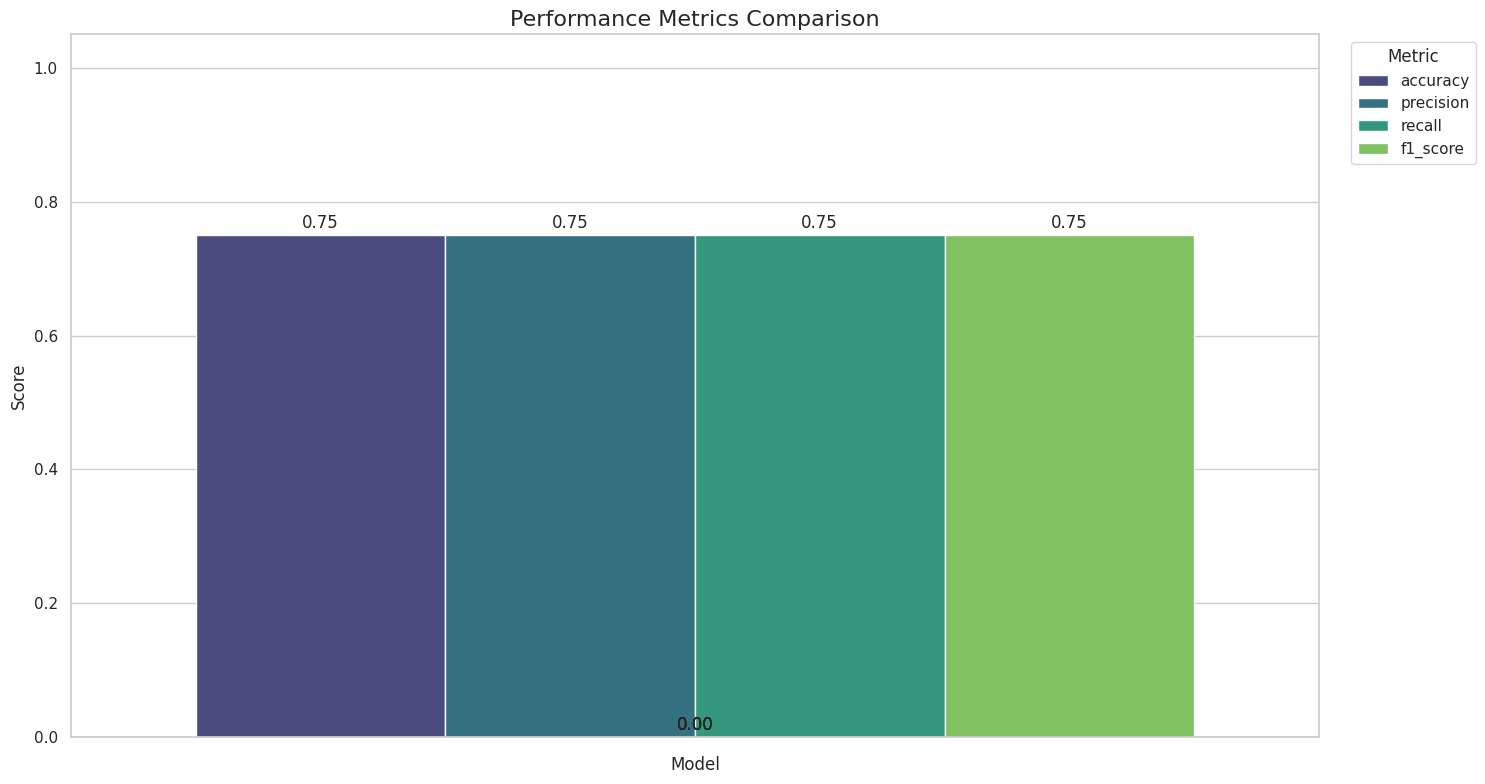

In [13]:
# performance metrics comparison chart

evaluation_results = []

evaluation_results.append({
        "name": '',
        "y_true": y_true,
        "y_pred": y_pred,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred)
    })

results_df = pd.DataFrame(evaluation_results)

df_melted = results_df.melt(
    id_vars='name',
    value_vars=['accuracy', 'precision', 'recall', 'f1_score'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_melted,
    x='name',
    y='Value',
    hue='Metric',
    palette='viridis'
)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.title('Performance Metrics Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1.05)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

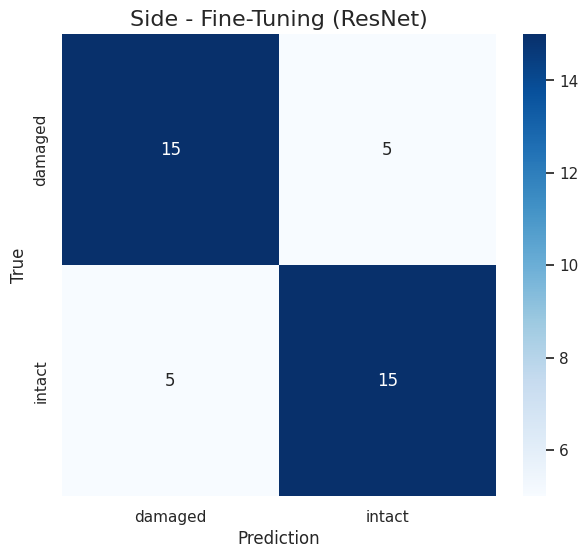

In [14]:
# confusion matrix visualization

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=['damaged', 'intact'], yticklabels=['damaged', 'intact'])
plt.title('Side - Fine-Tuning (ResNet)', fontsize=16)
plt.xlabel('Prediction', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.show()

In [15]:
# interpretability functions

def get_integrated_gradients(model, baseline_image, input_image, m_steps=50):
    interpolated_images = tf.stack(
        [baseline_image + (float(i)/m_steps) * (input_image - baseline_image) for i in range(m_steps + 1)]
    )

    with tf.GradientTape() as tape:
        tape.watch(interpolated_images)
        preds = model(interpolated_images)

    grads = tape.gradient(preds, interpolated_images)

    avg_grads = tf.reduce_mean(grads, axis=0)

    integrated_grads = (input_image - baseline_image) * avg_grads
    return integrated_grads

def visualize_attributions(image, attributions):
    attributions = tf.reduce_sum(tf.abs(attributions), axis=-1)

    attributions = (attributions - tf.reduce_min(attributions)) / (tf.reduce_max(attributions) - tf.reduce_min(attributions))

    plt.figure(figsize=(14, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(attributions, cmap='inferno')
    plt.title("Attribution Map (Interpretability)")
    plt.axis('off')

    plt.colorbar()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Analyzing an image with the true label: 'damaged'
The model predicted: 'damaged' with probability 0.00


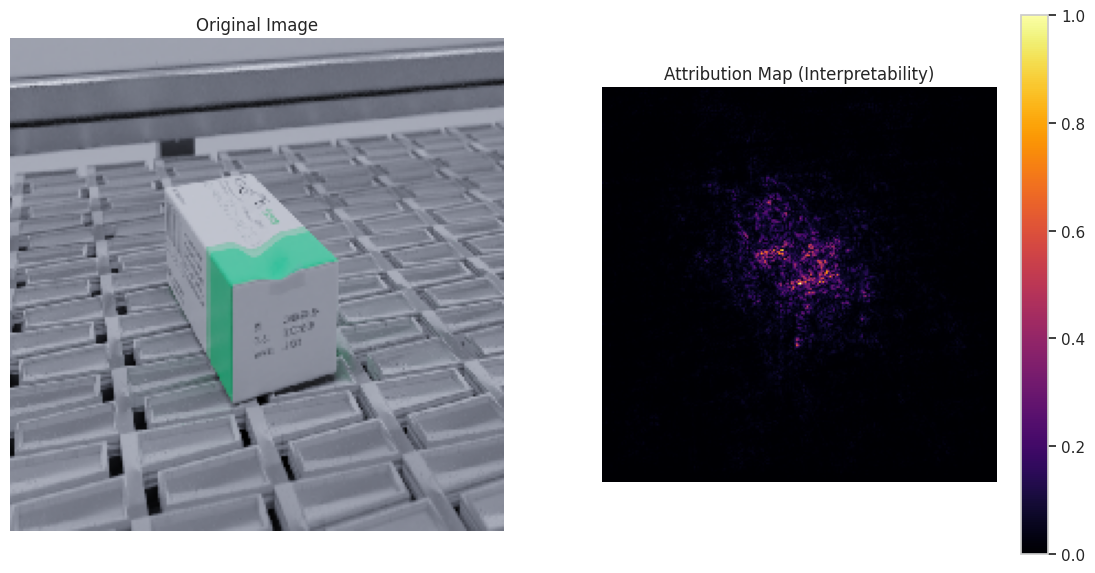

In [16]:
# applying interpretability to a test image

try:
    test_images, test_labels = next(test_generator)
except StopIteration:
    test_generator.reset()
    test_images, test_labels = next(test_generator)

damaged_indices = np.where(test_labels == 0)[0]

if len(damaged_indices) > 0:
    image_index = damaged_indices[0]
    image_to_explain = test_images[image_index]
    label_to_explain = test_labels[image_index]

    model_to_explain = final_model

    baseline = tf.zeros(shape=IMG_SIZE + (3,))

    ig_attributions = get_integrated_gradients(
        model=model_to_explain,
        baseline_image=baseline,
        input_image=image_to_explain
    )

    class_names = {v: k for k, v in test_generator.class_indices.items()}

    pred_proba = model_to_explain.predict(np.expand_dims(image_to_explain, axis=0))[0][0]
    pred_label_index = int(pred_proba > 0.5)

    print(f"Analyzing an image with the true label: '{class_names[int(label_to_explain)]}'")
    print(f"The model predicted: '{class_names[pred_label_index]}' with probability {pred_proba:.2f}")

    visualize_attributions(image_to_explain, ig_attributions)

else:
    print("No damaged image was found in this batch. Run the cell again to load a new batch.")